## Settings and imports

In [29]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import string
from torch import nn
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
import random

In [30]:
import json

with open('../config.json', 'r') as f:
    config = json.load(f)

which_dataset = config["which_dataset"]
preprocessing_method = config["preprocessing_method"] # normalization / logarithm
remove_outer = config["remove_outer"]
how_many_outer_to_remove = config["how_many_outer_to_remove"]
elements_to_keep = config["elements_to_keep"]

data_path = config["data_path"][which_dataset]
results_path = config["results_path"]
figures_path = config["figures_path"]
models_path = config["models_path"]

In [31]:
columns_to_keep_inds = [el + '_i' for el in elements_to_keep]
columns_to_keep_inks = [el + '_a' for el in elements_to_keep]

## Loading the data

In [32]:
df = pd.read_csv(data_path)
inks_df = df[[col for col in df.columns if col.endswith('_a')]]
inks_df.columns = [col.split('_')[0] for col in inks_df.columns]
inds_df = df[[col for col in df.columns if col.endswith('_i')]]
inds_df.columns = [col.split('_')[0] for col in inds_df.columns]

if which_dataset == 'old':
    df['sample_i'] = df['inds'].apply(lambda x: x.split('.')[0])
    df['sample_a'] = df['sample_i']
    df.rename(columns={'inds': 'name'}, inplace=True)

## Preprocessing

### Joining corresponding samples from inds and inks into one table

In [33]:
inDKs_df = df

### Keeping track of the records from the same sample

Check

In [34]:
all(inDKs_df['sample_i'] == inDKs_df['sample_a'])

True

We can use 'name' column as sample id:

In [35]:
inDKs_df['Sample_id'] = inDKs_df['sample_i']

### Removing some data

1. Let's remove 'outer' samples:

In [36]:
def remove_outer(group, n):
    return group.iloc[n:-n] if len(group) > 2*n else pd.DataFrame(columns=group.columns)

In [37]:
inDKs_df = inDKs_df.groupby('Sample_id', group_keys=False).apply(remove_outer, n=how_many_outer_to_remove)

/tmp/ipykernel_8236/3937849811.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  inDKs_df = inDKs_df.groupby('Sample_id', group_keys=False).apply(remove_outer, n=how_many_outer_to_remove)
/tmp/ipykernel_8236/3937849811.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  inDKs_df = inDKs_df.groupby('Sample_id', group_keys=False).apply(remove_outer, n=how_many_outer_to_remove)


2. Let's keep only columns that we need.

To reduce the set of used elements run cell below. Then, instead of predicting 29 numbers, we will predict only 8. We will also use only 8 numbers as input.

In [38]:
inDKs_df = inDKs_df[columns_to_keep_inks + columns_to_keep_inds + ['Sample_id', 'name'] ]

3. Let's remove rows with missing values.

In [39]:
(inDKs_df.shape[0] - inDKs_df.dropna().shape[0])/inDKs_df.shape[0]

0.0

4. Let's set negative numbers to zeros.

In [40]:
for col in columns_to_keep_inks + columns_to_keep_inds:
    inDKs_df[col][inDKs_df[col] < 0] = 0

/tmp/ipykernel_8236/1556174307.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  inDKs_df[col][inDKs_df[col] < 0] = 0
/tmp/ipykernel_8236/1556174307.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are 

5. (Optionally) let's set indicators to zero if the corresponding ink is zero.

In [41]:
# for i in range(len(elements_to_keep)):
#     inDKs_df.iloc[:,i+8] = np.where(inDKs_df.iloc[:,i]!=0, inDKs_df.iloc[:,i+8], 0)

In [42]:
#check
# element = 'Pb'
# inDKs_df[element + '_i'][np.logical_and(inDKs_df[element + '_a']==0, inDKs_df[element + '_i']!=0)]

### Normalization / taking logarithm

In [43]:
def adjusted_log_transform(input_array):
    res = np.where(input_array>0, np.log(input_array), 0)
    #res = np.where(input_array<=0, input_array + res.min(axis=0), res)
    return res

In [44]:
if preprocessing_method == 'logarithm':
    
    inDKs_df[columns_to_keep_inks + columns_to_keep_inds] = adjusted_log_transform(inDKs_df[columns_to_keep_inks + columns_to_keep_inds].values)

/tmp/ipykernel_8236/1905796701.py:2: RuntimeWarning: divide by zero encountered in log
  res = np.where(input_array>0, np.log(input_array), 0)


In [45]:
mean_df = inDKs_df[columns_to_keep_inks + ['Sample_id']]

for name in columns_to_keep_inks:
    mean_df[name] = inDKs_df.groupby('Sample_id')[name].transform('mean')
    mean_df.drop_duplicates('Sample_id', inplace=True)

mean_df['Sample_id'] = mean_df['Sample_id'].astype(str)
mean_df.sort_values(by='Sample_id', inplace=True)
mean_df.reset_index(drop=True, inplace=True)

/tmp/ipykernel_8236/1728332990.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df[name] = inDKs_df.groupby('Sample_id')[name].transform('mean')
/tmp/ipykernel_8236/1728332990.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_8236/1728332990.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/in

In [46]:
import plotly.express as px
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(inDKs_df[columns_to_keep_inks].values)
#means_tsne = tsne.transform(mean_df[[columns_to_keep_inks]].values)

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(inDKs_df[columns_to_keep_inks].values)

means_pca = pca.transform(mean_df[columns_to_keep_inks].values)

In [47]:
import numpy as np
import matplotlib.pyplot as plt

n_colors = inDKs_df['Sample_id'].nunique()

base_cmap = plt.get_cmap('hsv') 

colors = [base_cmap(i / n_colors) for i in range(n_colors)]

color_dict = dict(zip(np.random.permutation(inDKs_df['Sample_id'].unique()), colors))

In [48]:
#%matplotlib widget

/tmp/ipykernel_8236/4122908542.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


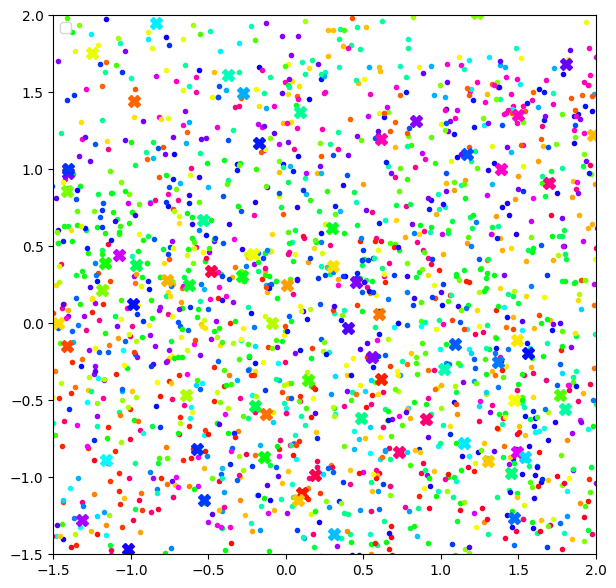

In [53]:
zoom = True

x_lower, x_upper = -1.5, 2
y_lower, y_upper = -1.5, 2

fig, ax = plt.subplots(figsize=(7,7))
for i, name in enumerate(inDKs_df['Sample_id']):
    ax.plot(X_pca[i, 0], X_pca[i, 1], marker='o', linestyle='', ms=3, color=color_dict[name])
    
for j, name in enumerate(mean_df['Sample_id']):
    ax.plot(means_pca[j, 0], means_pca[j, 1], marker='X', linestyle='', ms=9, color=color_dict[name])
ax.legend()

if zoom:
    ax.set_xlim(x_lower, x_upper)
    ax.set_ylim(y_lower, y_upper)
    
if zoom:
    plt.savefig(figures_path + 'PCA_and_class_centers_' + which_dataset + '_dataset_zoomed_' + \
                str(x_lower) + '_'+ str(x_upper) + '_' + str(y_lower) + '_' + str(y_upper) + '.png')
else:
    plt.savefig(figures_path + 'PCA_and_class_centers_' + which_dataset + '_dataset.png')

### Train test split, datasets, dataloaders

In [22]:
indices = list(range(int(inDKs_df.shape[0])))
ind_train_all, ind_test_all = train_test_split(indices, test_size=0.2, random_state=1)
ind_train_all, ind_val_all = train_test_split(ind_train_all, test_size=0.25, random_state=1)

partition = {'train': ind_train_all,
         'val': ind_val_all,
        'test': ind_test_all}

X_y_train = inDKs_df.iloc[partition['train'],:]
X_y_val = inDKs_df.iloc[partition['val'],:]
X_y_test = inDKs_df.iloc[partition['test'],:]

X_y_train.reset_index(drop=True, inplace=True)
X_y_val.reset_index(drop=True, inplace=True)
X_y_test.reset_index(drop=True, inplace=True)

### Creating features and labels matrices

In [23]:
train_order = X_y_train['Sample_id']
val_order = X_y_val['Sample_id']
test_order = X_y_test['Sample_id']

X_train = np.array(X_y_train[columns_to_keep_inds].values)
y_train = np.array(X_y_train[columns_to_keep_inks].values)
X_val = np.array(X_y_val[columns_to_keep_inds].values)
y_val = np.array(X_y_val[columns_to_keep_inks].values)
X_test = np.array(X_y_test[columns_to_keep_inds].values)
y_test = np.array(X_y_test[columns_to_keep_inks].values)

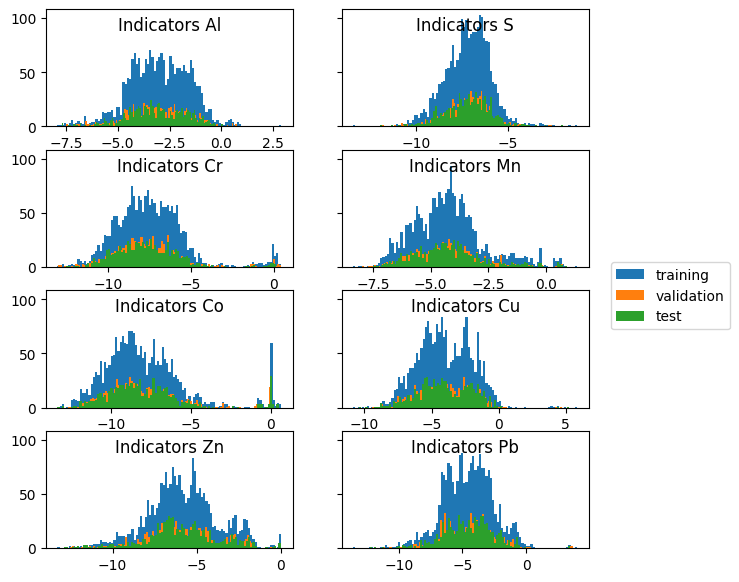

In [24]:
fig, axes = plt.subplots(4, 2, figsize=(7, 7), sharey=True) 

axes = axes.flatten()

for i in range(8):
    axes[i].hist(X_train[:,i], bins=100, label='training')
    axes[i].hist(X_val[:,i], bins=100, label='validation')
    axes[i].hist(X_test[:,i], bins=100, label='test')
    axes[i].set_title('Indicators ' + elements_to_keep[i], x=0.5, y=0.75)

plt.legend(bbox_to_anchor=(1.6,2.5))
plt.savefig(figures_path + 'indicators_train_val_test_histograms_' + which_dataset + '_dataset.png', bbox_inches='tight')

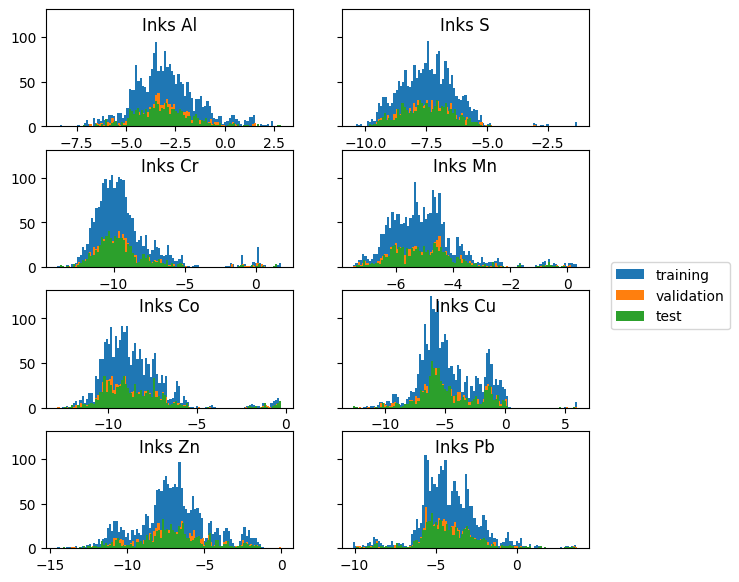

In [25]:
fig, axes = plt.subplots(4, 2, figsize=(7, 7), sharey=True) 

axes = axes.flatten()

for i in range(8):
    axes[i].hist(y_train[:,i], bins=100, label='training')
    axes[i].hist(y_val[:,i], bins=100, label='validation')
    axes[i].hist(y_test[:,i], bins=100, label='test')
    axes[i].set_title('Inks ' + elements_to_keep[i], x=0.5, y=0.75)

plt.legend(bbox_to_anchor=(1.6,2.5))
plt.savefig(figures_path + 'inks_train_val_test_histograms_' + which_dataset + '_dataset.png', bbox_inches='tight')

### Zoom on single elements

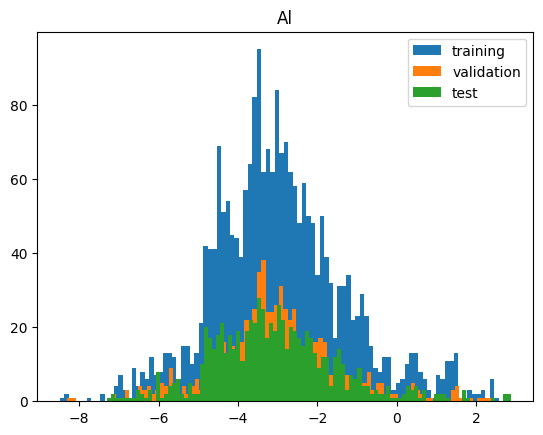

In [26]:
dim = 0
plt.hist(y_train[:,dim], bins=100, label='training');
plt.hist(y_val[:,dim], bins=100, label='validation');
plt.hist(y_test[:,dim], bins=100, label='test');
plt.title(elements_to_keep[dim])
plt.legend()

Cu >> Mn > Al > Zn > Pb > S > Cr > Co >>